In [3]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("Industrial.csv")

In [7]:
print(df.head())

print(df.info())

print(df.shape)

print(df.describe())

     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREE

In [9]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [11]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [13]:
print(df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [15]:
print(df.duplicated().sum())

0


In [17]:
df = df.drop_duplicates()

In [20]:
print(df.dtypes)

OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object


In [22]:
df["Date"] = pd.to_datetime(df["Date"])

In [24]:
print(df.dtypes)

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


In [26]:
num_cols = ["Quantity","UnitPrice","ItemsInCart","TotalPrice"]

print(df[num_cols].describe())

          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


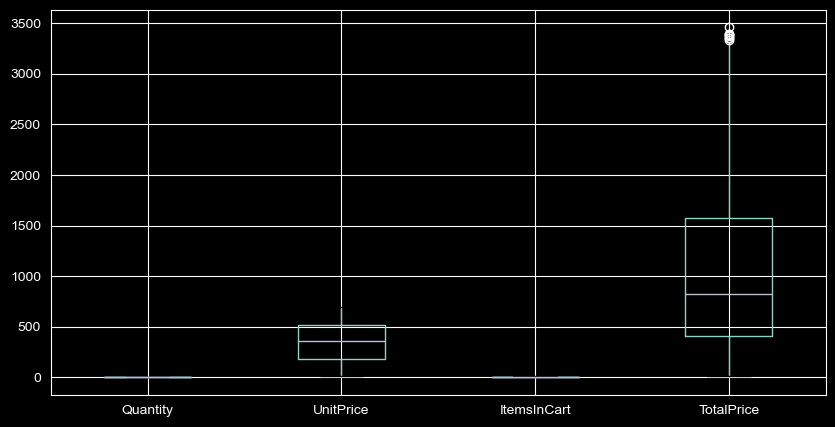

In [34]:
import matplotlib.pyplot as plt

df[num_cols].boxplot(figsize=(10,5))
plt.show()

In [35]:

print("Total Sales =", df["TotalPrice"].sum())
print("Average Sales =", df["TotalPrice"].mean())
print(df.loc[df["TotalPrice"].idxmax()])
print(df.loc[df["TotalPrice"].idxmin()])
print(df["OrderStatus"].value_counts())
print(df["PaymentMethod"].value_counts())
print(df.groupby("Product")["Quantity"].sum().sort_values(ascending=False))
df["Month"] = df["Date"].dt.month_name()
print(df.groupby("Month")["TotalPrice"].sum())



Total Sales = 1264761.96
Average Sales = 1053.9683
OrderID                      ORD200789
Date               2023-08-17 00:00:00
CustomerID                      C57276
Product                         Tablet
Quantity                             5
UnitPrice                       691.28
ShippingAddress            183 Main St
PaymentMethod                   Online
OrderStatus                  Delivered
TrackingNumber             TRK75899752
ItemsInCart                         10
CouponCode                      SAVE10
ReferralSource                   Email
TotalPrice                      3456.4
Month                           August
Name: 789, dtype: object
OrderID                      ORD201161
Date               2023-10-16 00:00:00
CustomerID                      C32570
Product                          Phone
Quantity                             1
UnitPrice                        11.39
ShippingAddress            826 Main St
PaymentMethod                     Cash
OrderStatus                

In [36]:
df.to_csv("Industrial_Cleaned.csv", index=False)

print("Dataset Saved Successfully")


Dataset Saved Successfully


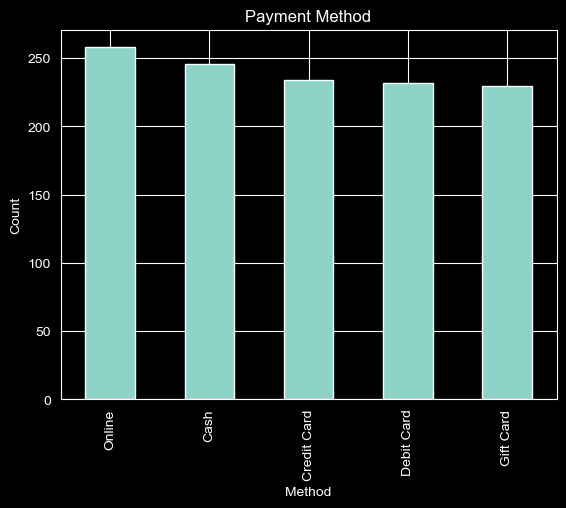

In [38]:
import matplotlib.pyplot as plt

df["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Payment Method")
plt.xlabel("Method")
plt.ylabel("Count")
plt.show()

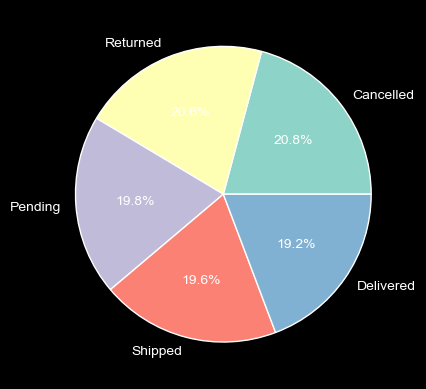

In [40]:
df["OrderStatus"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.show()

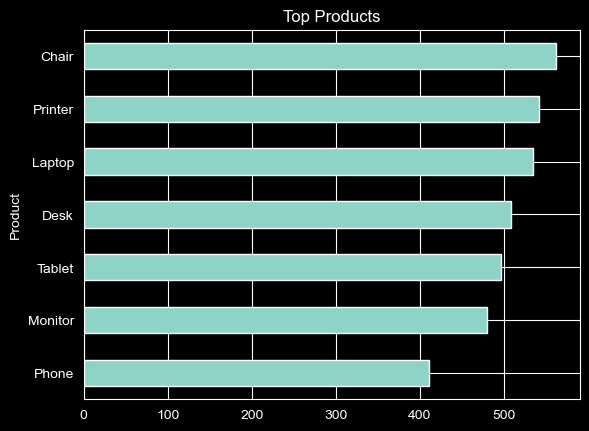

In [41]:
top = df.groupby("Product")["Quantity"].sum()

top.sort_values().tail(10).plot(kind="barh")

plt.title("Top Products")
plt.show()